# ✈️ San Francisco Airport Passenger Clustering

## Introduction

This project analyzes passenger traffic at **San Francisco International Airport (SFO)** and applies **K-Means clustering** to group similar passenger records.

The workflow includes exploratory data analysis, passenger traffic visualization, data preparation, the **Elbow Method with Yellowbrick**, K-Means clustering, silhouette evaluation, and cluster interpretation.

The main objective is to apply the clustering methods used in class to a real airport passenger dataset in a simple and structured way.

## Data Dictionary

| Column Name | Description |
| --- | --- |
| Activity Period | Reporting period of the passenger activity in YYYYMM format. |
| Operating Airline | Airline operating the flight. |
| Operating Airline IATA Code | IATA code of the operating airline. |
| Published Airline | Airline under which the flight is published. |
| Published Airline IATA Code | IATA code of the published airline. |
| GEO Summary | Indicates whether the traffic is Domestic or International. |
| GEO Region | Geographic region associated with the passenger traffic. |
| Activity Type Code | Passenger activity type: Enplaned, Deplaned, or Thru / Transit. |
| Price Category Code | Airline price category: Low Fare or Other. |
| Terminal | Airport terminal associated with the activity. |
| Boarding Area | Boarding area associated with the activity. |
| Passenger Count | Number of passengers recorded for the activity. |

## Import Libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

## Load Dataset

In [2]:
df = pd.read_csv("air-traffic-passenger-statistics.csv")

df.head()

,Activity Period,Operating Airline,Operating Airline IATA Code,Published Airline,Published Airline IATA Code,GEO Summary,GEO Region,Activity Type Code,Price Category Code,Terminal,Boarding Area,Passenger Count
0,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Deplaned,Low Fare,Terminal 1,B,27271
1,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Enplaned,Low Fare,Terminal 1,B,29131
2,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Thru / Transit,Low Fare,Terminal 1,B,5415
3,200507,Air Canada,AC,Air Canada,AC,International,Canada,Deplaned,Other,Terminal 1,B,35156
4,200507,Air Canada,AC,Air Canada,AC,International,Canada,Enplaned,Other,Terminal 1,B,34090


## Exploratory Data Analysis

In [4]:
df.shape

(18885, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18885 entries, 0 to 18884
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Activity Period              18885 non-null  int64
 1   Operating Airline            18885 non-null  str  
 2   Operating Airline IATA Code  18822 non-null  str  
 3   Published Airline            18885 non-null  str  
 4   Published Airline IATA Code  18822 non-null  str  
 5   GEO Summary                  18885 non-null  str  
 6   GEO Region                   18885 non-null  str  
 7   Activity Type Code           18885 non-null  str  
 8   Price Category Code          18885 non-null  str  
 9   Terminal                     18885 non-null  str  
 10  Boarding Area                18885 non-null  str  
 11  Passenger Count              18885 non-null  int64
dtypes: int64(2), str(10)
memory usage: 3.2 MB


In [6]:
df.isnull().sum()

Activity Period                 0
Operating Airline               0
Operating Airline IATA Code    63
Published Airline               0
Published Airline IATA Code    63
GEO Summary                     0
GEO Region                      0
Activity Type Code              0
Price Category Code             0
Terminal                        0
Boarding Area                   0
Passenger Count                 0
dtype: int64

In [7]:
df.describe()

,Activity Period,Passenger Count
count,18885.000000,18885.000000
mean,201179.285994,29876.744400
std,385.755460,60626.072969
min,200507.000000,1.000000
25%,200811.000000,5352.000000
50%,201204.000000,9170.000000
75%,201509.000000,20718.000000
max,201806.000000,659837.000000


### Data Cleaning

>The two IATA code columns contain a small number of missing values and are not required for this clustering analysis.  
`Published Airline` is also removed because the operating airline information is already available.

In [8]:
df = df.drop(columns=[
    "Operating Airline IATA Code",
    "Published Airline",
    "Published Airline IATA Code"
])

df.head()

,Activity Period,Operating Airline,GEO Summary,GEO Region,Activity Type Code,Price Category Code,Terminal,Boarding Area,Passenger Count
0,200507,ATA Airlines,Domestic,US,Deplaned,Low Fare,Terminal 1,B,27271
1,200507,ATA Airlines,Domestic,US,Enplaned,Low Fare,Terminal 1,B,29131
2,200507,ATA Airlines,Domestic,US,Thru / Transit,Low Fare,Terminal 1,B,5415
3,200507,Air Canada,International,Canada,Deplaned,Other,Terminal 1,B,35156
4,200507,Air Canada,International,Canada,Enplaned,Other,Terminal 1,B,34090


## Passenger Traffic Analysis

In [9]:
passenger_activity = df.groupby(
    ["Terminal", "Activity Type Code"]
)["Passenger Count"].sum().unstack()

passenger_activity

Activity Type Code,Deplaned,Enplaned,Thru / Transit
Terminal,,,
International,76528336.0,73901419.0,500289.0
Other,115.0,74.0,11.0
Terminal 1,65954200.0,66560010.0,190077.0
Terminal 2,26853636.0,27243703.0,NaN
Terminal 3,112489582.0,113293792.0,707074.0


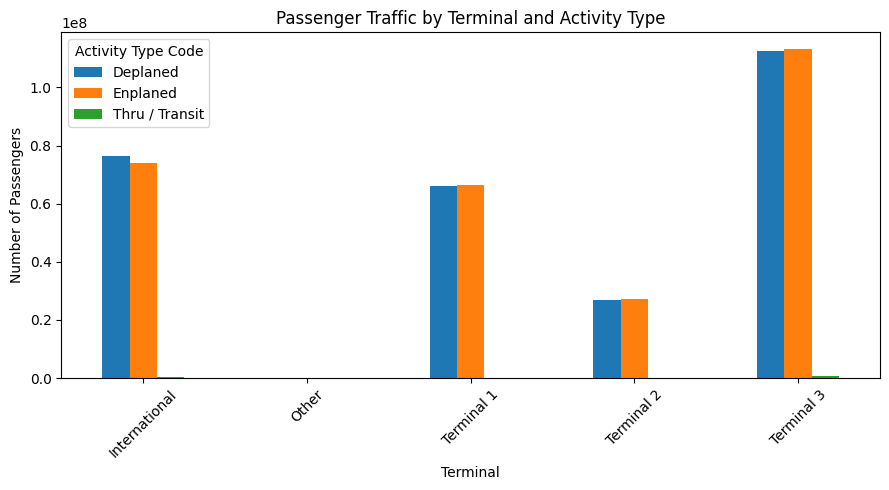

In [10]:
passenger_activity.plot(kind="bar", figsize=(9, 5))

plt.title("Passenger Traffic by Terminal and Activity Type")
plt.xlabel("Terminal")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

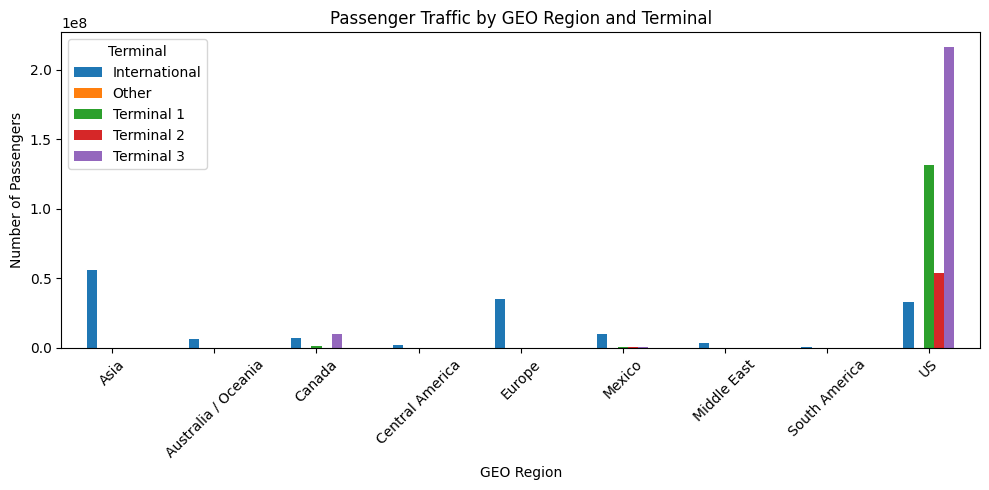

In [11]:
passenger_geo = df.groupby(
    ["GEO Region", "Terminal"]
)["Passenger Count"].sum().unstack()

passenger_geo.plot(kind="bar", figsize=(10, 5))

plt.title("Passenger Traffic by GEO Region and Terminal")
plt.xlabel("GEO Region")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

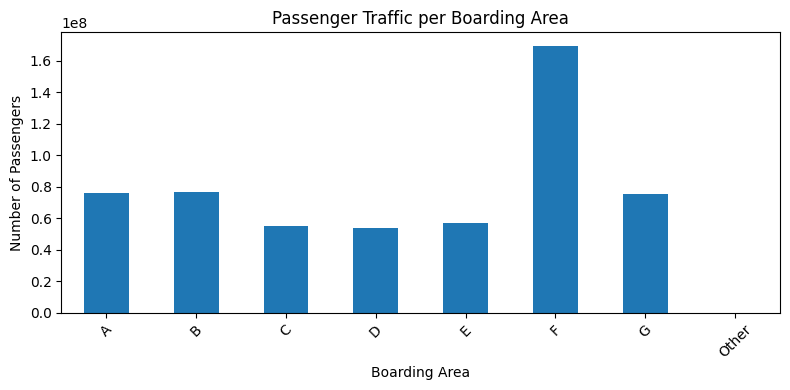

In [12]:
passenger_boarding = df.groupby(
    "Boarding Area"
)["Passenger Count"].sum()

passenger_boarding.plot(kind="bar", figsize=(8, 4))

plt.title("Passenger Traffic per Boarding Area")
plt.xlabel("Boarding Area")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

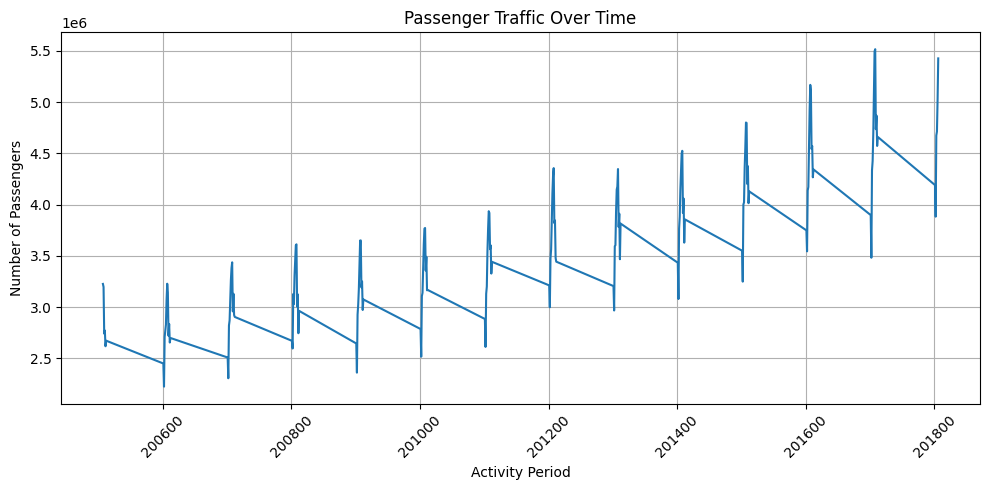

In [13]:
passenger_trends = df.groupby(
    "Activity Period"
)["Passenger Count"].sum()

passenger_trends.plot(
    kind="line",
    figsize=(10, 5)
)

plt.title("Passenger Traffic Over Time")
plt.xlabel("Activity Period")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

## Data Preparation for Clustering

For clustering, a small set of meaningful features is selected:

- **Passenger Count**
- **GEO Summary**
- **Activity Type Code**
- **Price Category Code**

Categorical variables are converted into numerical dummy variables.  
The features are then standardized before applying K-Means clustering.

In [14]:
x = df[
    [
        "Passenger Count",
        "GEO Summary",
        "Activity Type Code",
        "Price Category Code"
    ]
]

x = pd.get_dummies(x, drop_first=True)

x.head()

,Passenger Count,GEO Summary_International,Activity Type Code_Enplaned,Activity Type Code_Thru / Transit,Price Category Code_Other
0,27271,False,False,False,False
1,29131,False,True,False,False
2,5415,False,False,True,False
3,35156,True,False,False,True
4,34090,True,True,False,True


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

## Elbow Method

The **Elbow Method** is used to estimate a suitable number of clusters.

Yellowbrick visualizes the K-Means distortion score for different values of **k**

In [19]:
# Run this installation once if Yellowbrick is not already installed
#!pip install -q yellowbrick

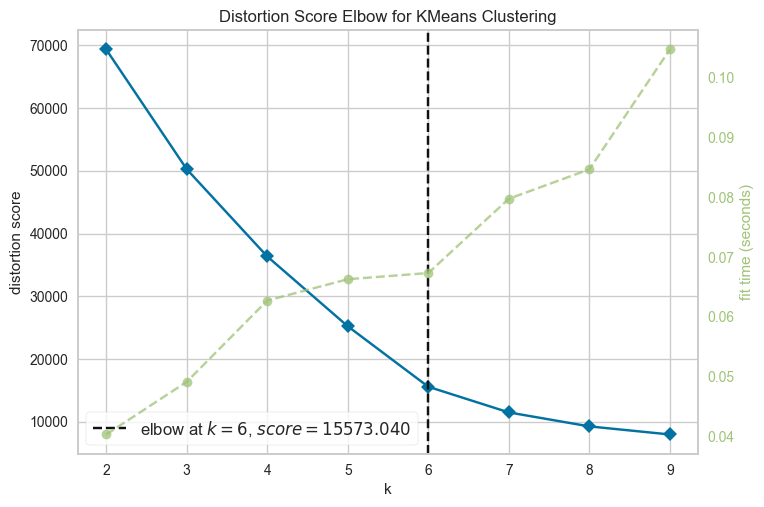

In [27]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

km = KMeans(random_state=42, n_init=10)

visualizer = KElbowVisualizer(
    km,
    k=(2, 10),
    force_model=True
)

visualizer.fit(x_scaled)
visualizer.show();

In [20]:
optimal_k = visualizer.elbow_value_

if optimal_k is None:
    optimal_k = 4

print("Optimal number of clusters:", optimal_k)

Optimal number of clusters: 6


>The Elbow Method suggests that **6 clusters** provide a suitable structure for the selected features

## K-Means Clustering

In [21]:
model = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

clusters = model.fit_predict(x_scaled)

In [22]:
df_clustered = df.copy()
df_clustered["Cluster"] = clusters

df_clustered.head()

,Activity Period,Operating Airline,GEO Summary,GEO Region,Activity Type Code,Price Category Code,Terminal,Boarding Area,Passenger Count,Cluster
0,200507,ATA Airlines,Domestic,US,Deplaned,Low Fare,Terminal 1,B,27271,4
1,200507,ATA Airlines,Domestic,US,Enplaned,Low Fare,Terminal 1,B,29131,4
2,200507,ATA Airlines,Domestic,US,Thru / Transit,Low Fare,Terminal 1,B,5415,2
3,200507,Air Canada,International,Canada,Deplaned,Other,Terminal 1,B,35156,3
4,200507,Air Canada,International,Canada,Enplaned,Other,Terminal 1,B,34090,1


## Cluster Evaluation

In [23]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    x_scaled,
    clusters,
    sample_size=5000,
    random_state=42
)

print("Silhouette Score:", round(score, 4))

Silhouette Score: 0.7127


## Cluster Analysis

In [24]:
cluster_summary = df_clustered.groupby(
    "Cluster"
)["Passenger Count"].agg(
    ["count", "mean", "median", "sum"]
)

cluster_summary.round(2)

,count,mean,median,sum
Cluster,,,,
0,449,340788.96,341404.0,153014245
1,5557,11529.94,8310.0,64071881
2,1046,1336.00,369.0,1397451
3,5537,11712.25,8394.0,64850704
4,2222,44701.41,17769.0,99326542
5,4074,44565.90,25993.5,181561495


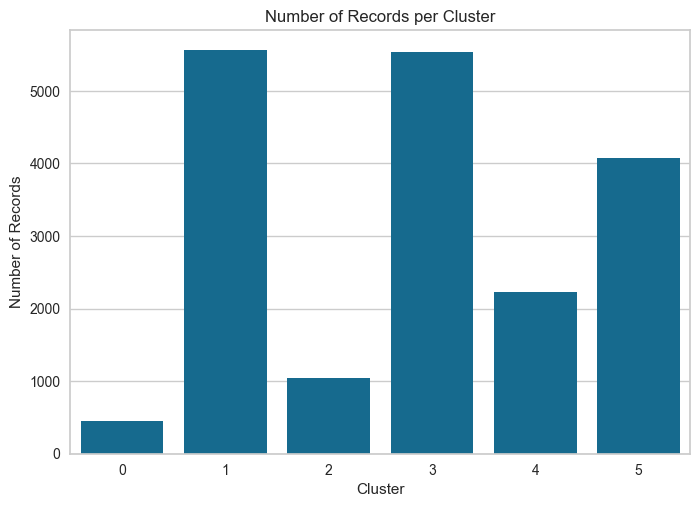

In [25]:
sns.countplot(
    x="Cluster",
    data=df_clustered
)

plt.title("Number of Records per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Records")
plt.show()

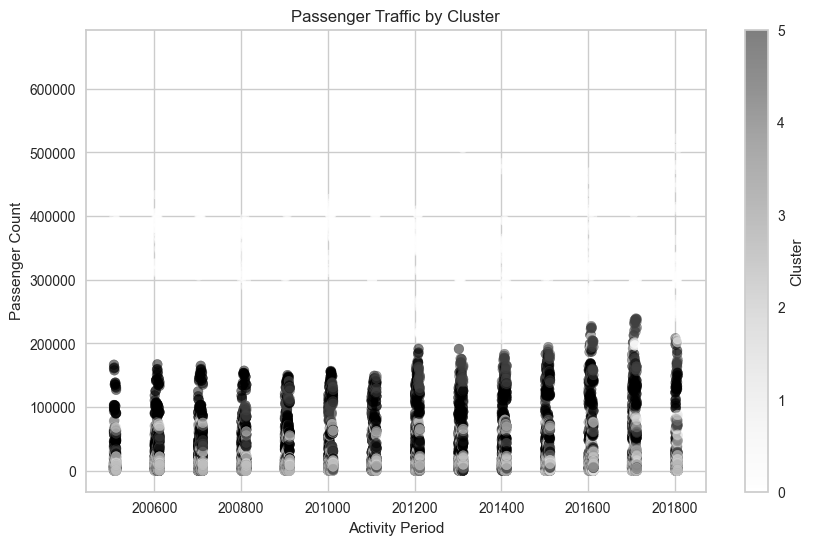

In [26]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_clustered["Activity Period"],
    df_clustered["Passenger Count"],
    c=df_clustered["Cluster"],
    alpha=0.5
)

plt.title("Passenger Traffic by Cluster")
plt.xlabel("Activity Period")
plt.ylabel("Passenger Count")
plt.colorbar(label="Cluster")
plt.show()

## Conclusion

This project applies **K-Means clustering** to passenger traffic data from San Francisco International Airport.

The analysis includes passenger traffic patterns by terminal, activity type, geographic region, boarding area, and activity period. For clustering, passenger count and selected categorical features were transformed and standardized.

The **Yellowbrick Elbow Method** identified **6 clusters** as a suitable solution.

The final K-Means model achieved a **Silhouette Score of 0.7127**, indicating a clear separation between the clusters for the selected feature representation.

The cluster analysis shows differences in passenger volume and passenger activity patterns across the six groups.

Overall, the project presents a simple clustering workflow using data exploration, feature preparation, the Elbow Method, K-Means clustering, silhouette evaluation, and cluster visualization.